<a href="https://colab.research.google.com/github/brauliotruylio/100days/blob/main/sistema-recomendacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instala a biblioteca do Kaggle
!pip install -q -U kaggle
!pip install --upgrade --force-reinstall --no-deps kaggle

!mkdir -p ~/.kaggle

with open('/root/.kaggle/kaggle.json', 'w') as file:
    file.write('{"username":"brauliotruylio","key":"5ff4e7be0bf3ed423cbc46fe2509a0f2"}')

!chmod 600 ~/.kaggle/kaggle.json

# Força o uso da versão 2.x do TensorFlow
%tensorflow_version 2.x

  Using cached kaggle-1.7.4.5-py3-none-any.whl.metadata (16 kB)
Using cached kaggle-1.7.4.5-py3-none-any.whl (181 kB)
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.7.4.5
    Uninstalling kaggle-1.7.4.5:
      Successfully uninstalled kaggle-1.7.4.5
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [2]:
# Baixa o dataset do Kaggle
!kaggle datasets download -d paramaggarwal/fashion-product-images-small

!unzip -q fashion-product-images-small.zip -d .

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
fashion-product-images-small.zip: Skipping, found more recently modified local copy (use --force to force download)
replace ./myntradataset/images/10000.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./myntradataset/images/10001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./myntradataset/images/10002.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./myntradataset/images/10003.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./myntradataset/images/10004.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./myntradataset/images/10005.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./myntradataset/images/10006.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./myntradataset/images/10007.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./myntradataset/images/10008.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./myntradataset/images/10009.jpg? 

In [3]:
import pandas as pd
from shutil import move
import os
from tqdm import tqdm

# Cria o diretório principal para os dados de moda
os.makedirs('/content/Fashion_data/categories', exist_ok=True)

# Lê o arquivo de metadados
df = pd.read_csv('/content/styles.csv', usecols=['id', 'masterCategory']).reset_index()
df['id'] = df['id'].astype('str')

all_images = os.listdir('/content/images/')
moved_count = 0

print("Organizando imagens em suas respectivas categorias...")
for image_filename in tqdm(all_images):
    # Encontra a categoria da imagem no DataFrame
    image_id = image_filename.split('.')[0]
    category_series = df[df['id'] == image_id]['masterCategory']

    if not category_series.empty:
        category = str(list(category_series)[0])

        # Cria a pasta da categoria se ela não existir
        category_path = os.path.join('/content/Fashion_data/categories', category)
        os.makedirs(category_path, exist_ok=True)

        # Move a imagem
        path_from = os.path.join('/content/images', image_filename)
        path_to = os.path.join(category_path, image_filename)
        move(path_from, path_to)
        moved_count += 1

print(f'Movidas {moved_count} imagens para os diretórios de categorias.')

Organizando imagens em suas respectivas categorias...


100%|██████████| 44441/44441 [02:59<00:00, 248.24it/s]

Movidas 44441 imagens para os diretórios de categorias.


In [4]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pylab as plt
import os

# Define o modelo pré-treinado que será usado (BiT)
MODULE_HANDLE = 'https://tfhub.dev/google/bit/m-r50x3/1'
# Define o tamanho para o qual as imagens serão redimensionadas
IMAGE_SIZE = (224, 224)
# Define o tamanho do vetor de características que o modelo irá gerar
N_FEATURES = 256

DATA_DIR = '/content/Fashion_data/categories'
BATCH_SIZE = 32

In [5]:
# Prepara os geradores de dados de treinamento e validação
datagen_kwargs = dict(rescale=1./255, validation_split=.20)
dataflow_kwargs = dict(target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, interpolation="bilinear")

# Gerador de dados de validação
valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**datagen_kwargs)
valid_generator = valid_datagen.flow_from_directory(
    DATA_DIR, subset="validation", shuffle=False, **dataflow_kwargs)

# Gerador de dados de treinamento
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**datagen_kwargs)
train_generator = train_datagen.flow_from_directory(
    DATA_DIR, subset="training", shuffle=True, **dataflow_kwargs)

Found 8886 images belonging to 7 classes.
Found 35555 images belonging to 7 classes.


In [8]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

print("Construindo o modelo com ResNet50V2 e a API Funcional...")

# 1. Carregar o modelo base ResNet50V2 pré-treinado no ImageNet
#    include_top=False: remove a camada final de classificação original.
base_model = ResNet50V2(
    include_top=False,
    weights='imagenet',
    input_shape=IMAGE_SIZE + (3,)
)

# 2. Congelar o modelo base para que seus pesos não sejam atualizados durante o treino
base_model.trainable = False

# 3. Construir nosso novo modelo no topo do ResNet50V2
#    Definir a entrada
inputs = base_model.input

#    A saída do modelo base é um mapa de características. Usamos GlobalAveragePooling2D para achatá-lo.
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)

#    Nossa camada de embedding (a que gera o vetor de características)
#    Damos um nome a ela para facilitar na hora de salvá-la depois
embedding_layer = Dense(N_FEATURES, kernel_regularizer=tf.keras.regularizers.l2(0.0001), name='embedding_layer')(x)

x = Dropout(0.2)(embedding_layer)

#    Camada de saída para o fine-tuning
outputs = Dense(train_generator.num_classes, kernel_regularizer=tf.keras.regularizers.l2(0.0001))(x)

# 4. Criar o modelo final
model = Model(inputs, outputs)

model.summary()

# A partir daqui, as células de model.compile() e model.fit() continuam as mesmas!

Construindo o modelo com ResNet50V2 e a API Funcional...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,091,143 (91.90 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [10]:
from google.colab import drive
drive.mount('/content/drive')

# Cria o diretório para salvar o modelo no Google Drive, se não existir
SAVE_PATH = '/content/drive/MyDrive/ImgSim/'
os.makedirs(SAVE_PATH, exist_ok=True)

# Cria o modelo extrator de características usando o nome da camada que definimos
feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.get_layer('embedding_layer').output
)

# Salva o extrator de características no novo formato .keras
# A linha abaixo foi corrigida
feature_extractor.save(os.path.join(SAVE_PATH, 'resnet_feature_extractor.keras'))
print("Modelo extrator de características (ResNet50V2) salvo com sucesso!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo extrator de características (ResNet50V2) salvo com sucesso!


In [11]:
# --- CÓDIGO PARA A NOVA CÉLULA (PASSO 4) ---

from pathlib import Path
import numpy as np
from tqdm import tqdm
import os
import tensorflow as tf

# Caminho onde os modelos foram salvos (você já definiu isso)
SAVE_PATH = '/content/drive/MyDrive/ImgSim/'

# Carrega o modelo salvo no formato .keras
# << ESTA É A LINHA QUE EU ESTAVA MENCIONANDO ANTES, JÁ CORRIGIDA
module = tf.keras.models.load_model(os.path.join(SAVE_PATH, 'resnet_feature_extractor.keras'))

# Função para carregar e pré-processar uma imagem
def load_img(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize_with_pad(img, 224, 224)
    img = tf.image.convert_image_dtype(img, tf.float32)[tf.newaxis, ...]
    return img

# Cria um diretório para salvar os vetores
imgvec_path = '/content/img_vectors/'
os.makedirs(imgvec_path, exist_ok=True)

# Lista os caminhos de todas as imagens
all_image_paths = list(Path('/content/Fashion_data/categories').rglob('*.jpg'))
# Para o exemplo, vamos usar um subconjunto de 5000 imagens
image_subset = all_image_paths[:5000]

print(f"Gerando vetores para {len(image_subset)} imagens...")
for filename in tqdm(image_subset):
    img = load_img(str(filename))
    features = module(img) # Gera o vetor
    feature_set = np.squeeze(features)

    # Salva o vetor em um arquivo .npz
    outfile_name = os.path.basename(filename).split('.')[0] + ".npz"
    out_path_file = os.path.join(imgvec_path, outfile_name)
    np.savetxt(out_path_file, feature_set, delimiter=',')

print("Vetorização concluída!")

Gerando vetores para 5000 imagens...


100%|██████████| 5000/5000 [17:59<00:00,  4.63it/s]

Vetorização concluída!


In [13]:
# Instala a biblioteca Annoy
!pip install -q annoy

import glob
from annoy import AnnoyIndex
import pickle
import numpy as np
import os
from tqdm import tqdm
import pandas as pd # Adicionado para garantir que o 'styles.csv' seja lido

# --- CÓDIGO PARA A NOVA CÉLULA (PASSO 5) ---

# Carrega os metadados novamente para mapear IDs de produtos
styles_df = pd.read_csv('/content/styles.csv', on_bad_lines='skip')
styles_df['id'] = styles_df['id'].astype('str')

# Dicionários para mapear índices, nomes de arquivos e IDs de produto
file_index_to_file_name = {}
file_index_to_product_id = {}

# Configuração do Annoy (N_FEATURES foi definido como 256 anteriormente)
dims = N_FEATURES
trees = 10000
t = AnnoyIndex(dims, metric='angular')

# Lista todos os arquivos de vetores que criamos
all_vector_files = glob.glob('/content/img_vectors/*.npz')

print(f"Construindo o índice Annoy com {len(all_vector_files)} vetores...")
for findex, fname in tqdm(enumerate(all_vector_files)):
    # Carrega o vetor do arquivo
    file_vector = np.loadtxt(fname)

    # Pega o nome base do arquivo (ex: "15970")
    file_name = os.path.basename(fname).split('.')[0]

    # Encontra o índice original do produto no dataframe 'styles.csv'
    product_id = styles_df.index[styles_df.id==file_name].values[0]

    # Preenche os dicionários
    file_index_to_file_name[findex] = file_name
    file_index_to_product_id[findex] = product_id

    # Adiciona o vetor ao índice Annoy
    t.add_item(findex, file_vector)

# Constrói o índice (pode levar alguns minutos)
print("Construindo as árvores do índice...")
t.build(trees)
print("Índice construído.")

# Salva o índice e os dicionários no Google Drive
SAVE_PATH = '/content/drive/MyDrive/ImgSim/' # Garante que a variável SAVE_PATH exista
t.save(os.path.join(SAVE_PATH, 'indexer.ann'))
pickle.dump(file_index_to_file_name, open(os.path.join(SAVE_PATH, "file_index_to_file_name.p"), "wb"))
pickle.dump(file_index_to_product_id, open(os.path.join(SAVE_PATH, "file_index_to_product_id.p"), "wb")) # Salva o novo mapeamento também

print("Índice e mapeamentos salvos no Google Drive com sucesso!")

Construindo o índice Annoy com 5000 vetores...


5000it [00:21, 229.86it/s]


Construindo as árvores do índice...
Índice construído.
Índice e mapeamentos salvos no Google Drive com sucesso!


Carregando todos os componentes para o teste...
Componentes carregados. Realizando a busca por similaridade...


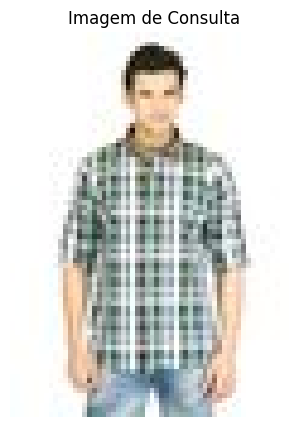


--- IMAGENS RECOMENDADAS ---


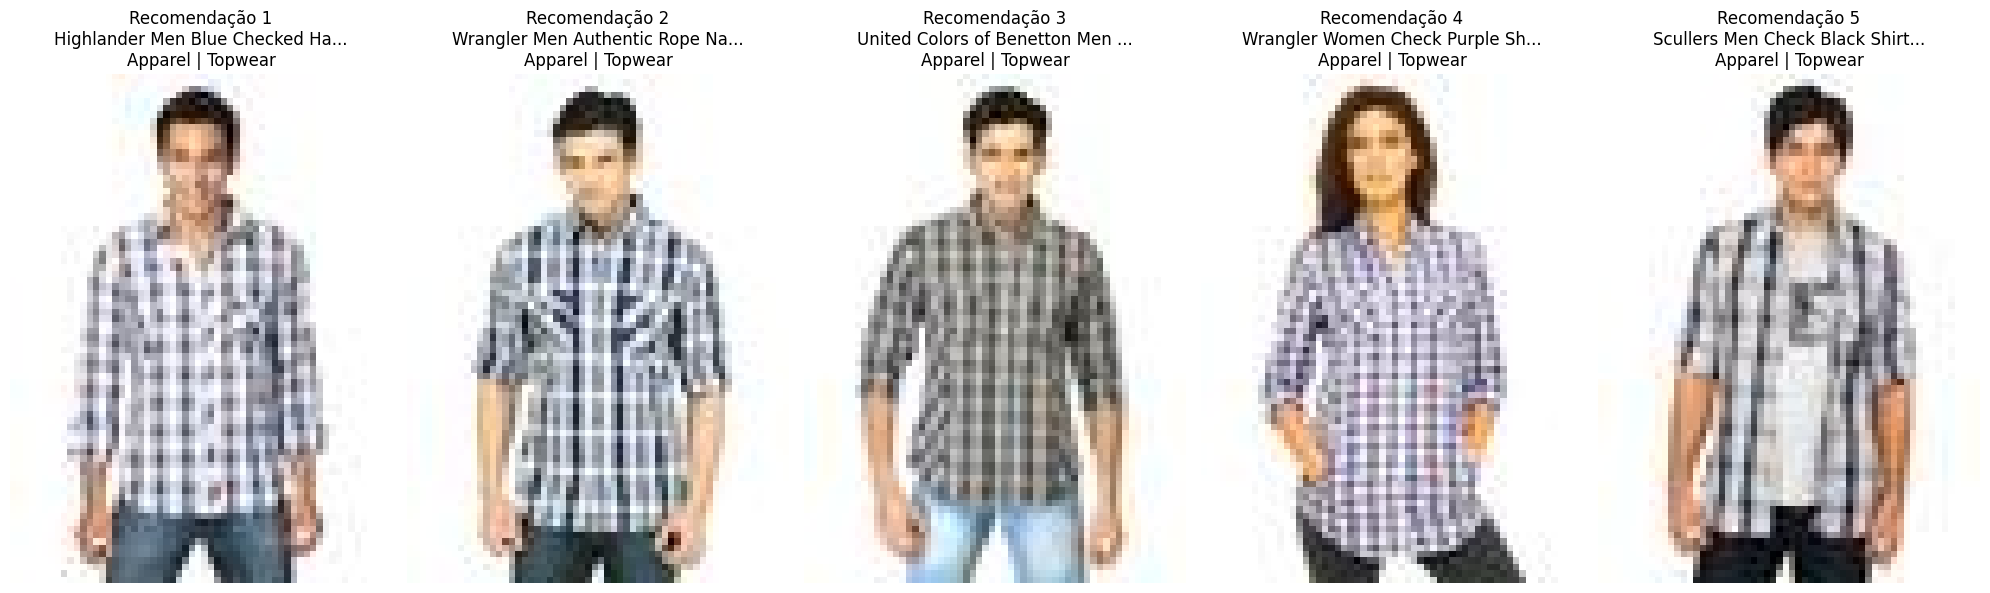

In [14]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pickle
from annoy import AnnoyIndex
import os
import tensorflow as tf
from pathlib import Path
import numpy as np
import pandas as pd

# --- CÓDIGO PARA A NOVA CÉLULA (PASSO 6 - TESTE FINAL) ---

print("Carregando todos os componentes para o teste...")

# Variáveis de configuração (garantir que existam na sessão)
SAVE_PATH = '/content/drive/MyDrive/ImgSim/'
N_FEATURES = 256
dims = N_FEATURES

# Função para carregar imagem (necessária se a sessão foi reiniciada)
def load_img(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize_with_pad(img, 224, 224)
    img = tf.image.convert_image_dtype(img, tf.float32)[tf.newaxis, ...]
    return img

# Carrega o modelo extrator de características
module = tf.keras.models.load_model(os.path.join(SAVE_PATH, 'resnet_feature_extractor.keras'))

# Carrega os mapeamentos, o índice Annoy e o dataframe de estilos
file_index_to_file_name = pickle.load(open(os.path.join(SAVE_PATH, "file_index_to_file_name.p"), "rb"))
file_index_to_product_id = pickle.load(open(os.path.join(SAVE_PATH, "file_index_to_product_id.p"), "rb"))
styles_df = pd.read_csv('/content/styles.csv', on_bad_lines='skip')
styles_df['id'] = styles_df['id'].astype('str')

t = AnnoyIndex(dims, metric='angular')
t.load(os.path.join(SAVE_PATH, 'indexer.ann'))

# Dicionário para encontrar o caminho completo da imagem pelo nome do arquivo
all_image_paths = list(Path('/content/Fashion_data/categories').rglob('*.jpg'))
path_dict = {path.name.split('.')[0]: str(path) for path in all_image_paths}

print("Componentes carregados. Realizando a busca por similaridade...")

# Pega um nome de arquivo aleatório do nosso índice para testar
random_filename = random.choice(list(file_index_to_file_name.values()))
query_image_path = path_dict[random_filename]

# Gera o vetor para a imagem de consulta
query_vector = np.squeeze(module(load_img(query_image_path)))

# Exibe a imagem de consulta
plt.figure(figsize=(5, 5))
plt.imshow(mpimg.imread(query_image_path))
plt.title("Imagem de Consulta")
plt.axis('off')
plt.show()

# Encontra os vizinhos mais próximos (imagens similares)
# Pede 6 resultados, pois o primeiro será a própria imagem de consulta
nns = t.get_nns_by_vector(query_vector, n=6)

# Exibe os resultados
print("\n--- IMAGENS RECOMENDADAS ---")
plt.figure(figsize=(20, 10))
# Pula o primeiro resultado (índice 0) que é a própria imagem
for i, index in enumerate(nns[1:]):
    filename = file_index_to_file_name[index]
    image_path = path_dict[filename]
    product_id = file_index_to_product_id[index]

    # Busca informações do produto para o título
    title_info = styles_df.loc[product_id]
    title = f"{title_info['productDisplayName'][:30]}...\n{title_info['masterCategory']} | {title_info['subCategory']}"

    plt.subplot(1, 5, i + 1)
    plt.imshow(mpimg.imread(image_path))
    plt.title(f"Recomendação {i+1}\n{title}")
    plt.axis('off')

plt.tight_layout()
plt.show()